# Olist — Data Profiling de `olist_orders_dataset.csv`

Análise exploratória inicial da tabela de pedidos do dataset público de e-commerce brasileiro (Olist), usando **profiling automatizado** (`fg-data-profiling`, sucessor do `ydata-profiling` / `pandas-profiling`).

O profiling entrega de graça toda a parte mecânica da EDA: tipagem, cardinalidade, distribuições, nulos, duplicatas, correlações e alertas de qualidade. O que ele **não** faz — e por isso as seções 5 a 8 existem — é entender o domínio: aqui, as colunas de data só viram informação quando viram *diferenças* (tempo de entrega, atraso), e a ordem lógica dos eventos precisa ser validada à mão.

## Dicionário de dados

| Coluna | Descrição |
|---|---|
| `order_id` | Identificador único do pedido (chave primária) |
| `customer_id` | Chave do cliente **para este pedido** (liga com `olist_customers_dataset`) |
| `order_status` | Estado do pedido (`delivered`, `shipped`, `canceled`, ...) |
| `order_purchase_timestamp` | Momento da compra |
| `order_approved_at` | Momento da aprovação do pagamento |
| `order_delivered_carrier_date` | Postagem: entrega do pedido à transportadora |
| `order_delivered_customer_date` | Entrega efetiva ao cliente |
| `order_estimated_delivery_date` | Prazo prometido ao cliente na compra |

## Roteiro

1. Carregamento e tipagem
2. Perfil bruto → relatório HTML
3. Como ler o relatório
4. Extração programática (alertas e estatísticas)
5. Features de tempo derivadas → perfil enriquecido
6. Comparativo: entregas no prazo × atrasadas
7. Checagens de consistência temporal
8. Visão temporal agregada
9. Conclusões e próximos passos

## 0. Ambiente

> **Nota de instalação.** O `ydata-profiling` foi renomeado: o pacote atual é **`fg-data-profiling`** e o import é `data_profiling`. Ele também exige Python ≤ 3.13 e ainda usa `pkg_resources`, removido do `setuptools` ≥ 81. O projeto já está configurado para isso:
>
> ```bash
> uv add fg-data-profiling "setuptools<81"   # requires-python = "~=3.12.0"
> ```

In [1]:
%matplotlib inline

import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from data_profiling import ProfileReport, compare

warnings.filterwarnings("ignore", category=FutureWarning)
# Ruído interno da própria biblioteca de profiling, não do nosso código
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# Paleta e estilo dos poucos gráficos manuais (seção 8)
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
INK, INK_SOFT, LINHA, SURFACE = "#0b0b0b", "#52514e", "#c9c8c3", "#fcfcfb"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.edgecolor": LINHA,
    "axes.labelcolor": INK_SOFT,
    "axes.titlecolor": INK,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.titlepad": 12,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e7e6e2",
    "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT,
    "ytick.color": INK_SOFT,
    "xtick.bottom": False,
    "ytick.left": False,
    "font.size": 10,
    "lines.linewidth": 2,
})

MILHAR = mticker.FuncFormatter(lambda v, _: format(int(v), ",").replace(",", "."))

print("pandas", pd.__version__)

pandas 2.3.3


## 1. Carregamento

As cinco colunas de data são convertidas para `datetime` **já na leitura**. Isso não é detalhe: se chegarem como texto, o profiling as classifica como `Categorical` de altíssima cardinalidade e todo o bloco de análise temporal do relatório se perde.

In [2]:
def encontrar_raiz(inicio: Path | None = None) -> Path:
    """Sobe na árvore de diretórios até achar a pasta data/raw do projeto."""
    inicio = inicio or Path.cwd()
    for p in [inicio, *inicio.parents]:
        if (p / "data" / "raw").exists():
            return p
    raise FileNotFoundError(f"Pasta data/raw não encontrada a partir de {inicio}")


PROJ_ROOT = encontrar_raiz()
CSV_PATH = PROJ_ROOT / "data" / "raw" / "archive" / "olist_orders_dataset.csv"
REPORTS_DIR = PROJ_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

COLS_DATA = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders = pd.read_csv(CSV_PATH, parse_dates=COLS_DATA)

print(f"Arquivo : {CSV_PATH.relative_to(PROJ_ROOT)}")
print(f"Formato : {orders.shape[0]} linhas x {orders.shape[1]} colunas")
print(f"Memória : {orders.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
orders.head()

Arquivo : data/raw/archive/olist_orders_dataset.csv
Formato : 99441 linhas x 8 colunas
Memória : 24.7 MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


## 2. Perfil bruto

### Configuração

Dois ajustes não são opcionais neste dataset — sem eles o relatório fica lento e pior:

- **`vars.cat.words/characters = False`** — `order_id` e `customer_id` têm ~99 mil valores únicos. Rodar análise de palavras/caracteres e nuvem de palavras sobre hashes é caro e não informa nada.
- **`interactions.continuous = False`** — os gráficos de dispersão cruzam todo par de numéricas com 99 mil pontos cada. Ligue apenas quando quiser investigar um par específico.

O bloco `dataset`/`variables` embute a documentação **dentro** do HTML — o relatório vira entregável autoexplicativo, não um dump anônimo.

In [3]:
DESCRICOES = {
    "order_id": "Identificador único do pedido (chave primária).",
    "customer_id": "Chave do cliente PARA ESTE PEDIDO — não identifica a pessoa.",
    "order_status": "Estado do pedido no ciclo de vida (delivered, shipped, canceled, ...).",
    "order_purchase_timestamp": "Momento da compra.",
    "order_approved_at": "Momento da aprovação do pagamento.",
    "order_delivered_carrier_date": "Postagem: entrega do pedido à transportadora.",
    "order_delivered_customer_date": "Entrega efetiva ao cliente.",
    "order_estimated_delivery_date": "Prazo prometido ao cliente no momento da compra.",
}

METADADOS = {
    "description": (
        "Tabela de pedidos do Brazilian E-Commerce Public Dataset by Olist. "
        "Uma linha por pedido, com o ciclo de vida completo em timestamps."
    ),
    "url": "https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce",
    "copyright_holder": "Olist",
    "creator": "Olist Store",
}

CONFIG_BASE = dict(
    explorative=True,
    vars={"cat": {"words": False, "characters": False}},
    interactions={"continuous": False},
    correlations={"auto": {"calculate": True}},
    missing_diagrams={"bar": True, "matrix": True, "heatmap": True},
    samples={"head": 10, "tail": 10},
    progress_bar=False,
)

In [4]:
HTML_BRUTO = REPORTS_DIR / "olist_orders_profiling.html"

t0 = time.perf_counter()
perfil_bruto = ProfileReport(
    orders,
    title="Olist — Pedidos (dados brutos)",
    dataset=METADADOS,
    variables={"descriptions": DESCRICOES},
    type_schema={"order_status": "categorical"},
    **CONFIG_BASE,
)
perfil_bruto.to_file(HTML_BRUTO)

print(f"Relatório salvo em: {HTML_BRUTO.relative_to(PROJ_ROOT)}")
print(f"Tamanho          : {HTML_BRUTO.stat().st_size / 1024**2:.1f} MB")
print(f"Tempo            : {time.perf_counter() - t0:.1f}s")

Relatório salvo em: reports/olist_orders_profiling.html
Tamanho          : 1.7 MB
Tempo            : 2.1s


In [5]:
# O relatório embutido pesa vários MB no .ipynb — ligue só quando for explorar.
# Alternativa: abrir o HTML salvo direto no navegador.
MOSTRAR_INLINE = False

if MOSTRAR_INLINE:
    perfil_bruto.to_notebook_iframe()

## 3. Como ler o relatório

| Aba | O que procurar aqui |
|---|---|
| **Overview → Alerts** | Comece por aqui. Cada alerta é uma hipótese de problema já formulada. |
| **Overview → Reproduction** | Config e versões usadas — é o que torna o relatório auditável. |
| **Variables** | Por coluna: tipo inferido, distintos, nulos, distribuição, valores extremos. |
| **Interactions** | Dispersão par a par (desligada aqui por custo). |
| **Correlations** | Auto/Spearman/Pearson/Phi-K/Cramér's V. Phi-K é o útil aqui: captura relação **não linear e entre tipos mistos** (ex.: categoria × numérica). |
| **Missing values** | *Matrix* e *Heatmap* mostram se os nulos são **correlacionados** — o sinal de que a ausência é estrutural, não aleatória. |
| **Sample / Duplicate rows** | Primeiras e últimas linhas e duplicatas exatas. |

> **A leitura mais importante deste dataset está no Missing values → Heatmap:** as datas de postagem e entrega faltam *juntas*, nas mesmas linhas. Isso prova que o nulo significa "o evento nunca aconteceu" (pedido cancelado/indisponível) e **não** falha de coleta — logo, imputar por média/mediana seria erro conceitual.

## 4. Extração programática

O HTML é para leitura humana. Para automação — testes de qualidade, CI, comparação entre versões do dado — use o `description_set`, que expõe tudo em objetos Python.

In [6]:
descricao = perfil_bruto.get_description()

alertas = pd.DataFrame(
    [
        {
            "coluna": getattr(a, "column_name", None) or "—",
            "tipo": str(getattr(a, "alert_type", "")).split(".")[-1],
            "detalhe": str(a),
        }
        for a in descricao.alerts
    ]
)

print(f"{len(alertas)} alertas de qualidade levantados automaticamente")
alertas

5 alertas de qualidade levantados automaticamente


,coluna,tipo,detalhe
0,order_status,IMBALANCE,[order_status] is highly imbalanced (0.9139469...
1,order_delivered_carrier_date,MISSING,[order_delivered_carrier_date] 1783 (1.8%) mis...
2,order_delivered_customer_date,MISSING,[order_delivered_customer_date] 2965 (3.0%) mi...
3,order_id,UNIQUE,[order_id] has unique values
4,customer_id,UNIQUE,[customer_id] has unique values


In [7]:
tabela = descricao.table

print("=" * 58)
print("ESTATÍSTICAS GERAIS (description_set.table)")
print("=" * 58)
print(f"Linhas                 : {tabela['n']}")
print(f"Colunas                : {tabela['n_var']}")
print(f"Células ausentes       : {tabela['n_cells_missing']} ({tabela['p_cells_missing'] * 100:.2f}%)")
print(f"Colunas com algum nulo : {tabela['n_vars_with_missing']}")
print(f"Linhas duplicadas      : {tabela['n_duplicates']}")
print(f"Tipos inferidos        : {dict(tabela['types'])}")
print("=" * 58)

# Resumo por variável, direto do objeto de descrição
pd.DataFrame(
    {
        col: {
            "tipo": stats.get("type"),
            "distintos": stats.get("n_distinct"),
            "pct_distintos": round(stats.get("p_distinct", 0) * 100, 2),
            "nulos": stats.get("n_missing"),
            "pct_nulos": round(stats.get("p_missing", 0) * 100, 2),
        }
        for col, stats in descricao.variables.items()
    }
).T

ESTATÍSTICAS GERAIS (description_set.table)
Linhas                 : 99441
Colunas                : 8
Células ausentes       : 4908 (0.62%)
Colunas com algum nulo : 3
Linhas duplicadas      : 0
Tipos inferidos        : {'Text': 2, 'Categorical': 1, 'DateTime': 5}


,tipo,distintos,pct_distintos,nulos,pct_nulos
order_id,Text,99441,100.0,0,0.0
customer_id,Text,99441,100.0,0,0.0
order_status,Categorical,8,0.01,0,0.0
order_purchase_timestamp,DateTime,98875,99.43,0,0.0
order_approved_at,DateTime,90733,91.39,160,0.16
order_delivered_carrier_date,DateTime,81018,82.96,1783,1.79
order_delivered_customer_date,DateTime,95664,99.16,2965,2.98
order_estimated_delivery_date,DateTime,459,0.46,0,0.0


**Leitura dos alertas.** Três padrões aparecem e cada um pede uma ação diferente:

- `UNIQUE` em `order_id` **e** em `customer_id` — confirma a granularidade (1 linha = 1 pedido) e revela a pegadinha clássica do Olist: `customer_id` é chave *por pedido*, não por pessoa. Esta tabela sozinha **não** identifica clientes recorrentes; para recompra é preciso o `customer_unique_id`, em `olist_customers_dataset.csv`.
- `MISSING` nas datas de postagem/entrega — ausência estrutural (ver seção 3), não sujeira.
- `IMBALANCE` em `order_status` — `delivered` domina (~97%). Qualquer alvo derivado de cancelamento é problema de classe rara: acurácia é métrica inútil, e será preciso `class_weight`/reamostragem e avaliação por PR-AUC ou recall.

## 5. Features de tempo → perfil enriquecido

Aqui está o limite do profiling automatizado: ele descreve as colunas que existem. Num dataset de ciclo de vida, a informação está nas **diferenças** entre os timestamps — e essas colunas precisam ser criadas antes de valer a pena perfilar.

| Feature | O que mede |
|---|---|
| `h_aprovacao` | horas entre compra e aprovação do pagamento |
| `d_ate_postagem` | dias entre compra e entrega à transportadora (gargalo do vendedor) |
| `d_entrega_total` | dias entre compra e entrega ao cliente (o que o cliente sente) |
| `d_prazo_prometido` | dias entre compra e a data estimada informada |
| `d_folga` | dias de folga sobre o prazo — **negativo = atraso** |
| `atrasado` | booleano derivado de `d_folga` (nulo quando não houve entrega) |

In [8]:
def delta(fim, inicio, unidade="D"):
    divisor = {"h": 3600, "D": 86400}[unidade]
    return (orders[fim] - orders[inicio]).dt.total_seconds() / divisor


orders["h_aprovacao"] = delta("order_approved_at", "order_purchase_timestamp", "h")
orders["d_ate_postagem"] = delta("order_delivered_carrier_date", "order_purchase_timestamp")
orders["d_entrega_total"] = delta("order_delivered_customer_date", "order_purchase_timestamp")
orders["d_prazo_prometido"] = delta("order_estimated_delivery_date", "order_purchase_timestamp")
orders["d_folga"] = delta("order_estimated_delivery_date", "order_delivered_customer_date")

# Atraso só é definido para pedidos efetivamente entregues (NA nos demais)
orders["atrasado"] = (orders["d_folga"] < 0).astype("boolean").mask(orders["d_folga"].isna())

# Recortes temporais da compra
orders["ano_mes"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders["dia_semana"] = orders["order_purchase_timestamp"].dt.day_name()
orders["hora"] = orders["order_purchase_timestamp"].dt.hour

METRICAS = ["h_aprovacao", "d_ate_postagem", "d_entrega_total", "d_prazo_prometido", "d_folga"]
orders[METRICAS].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(2)

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
h_aprovacao,99281.0,10.42,26.04,0.00,0.00,0.22,0.34,14.58,48.46,90.17,4509.18
d_ate_postagem,97658.0,3.23,3.61,-171.21,0.09,1.13,2.20,4.07,8.88,17.82,125.78
d_entrega_total,96476.0,12.56,9.55,0.53,1.83,6.77,10.22,15.72,29.28,46.05,209.63
d_prazo_prometido,99441.0,23.77,8.83,1.65,6.02,18.33,23.24,28.42,38.48,50.42,155.14
d_folga,96476.0,11.18,10.19,-188.98,-18.94,6.39,11.95,16.24,25.94,35.15,146.02


In [9]:
HTML_ENRIQUECIDO = REPORTS_DIR / "olist_orders_profiling_enriquecido.html"

# IDs fora: já sabemos que são chaves únicas e só poluem o relatório
COLS_PERFIL = [c for c in orders.columns if c not in ("order_id", "customer_id", "ano_mes")]

t0 = time.perf_counter()
perfil_enriquecido = ProfileReport(
    orders[COLS_PERFIL],
    title="Olist — Pedidos (com features de tempo)",
    dataset=METADADOS,
    **CONFIG_BASE,
)
perfil_enriquecido.to_file(HTML_ENRIQUECIDO)

print(f"Relatório salvo em: {HTML_ENRIQUECIDO.relative_to(PROJ_ROOT)}")
print(f"Tamanho          : {HTML_ENRIQUECIDO.stat().st_size / 1024**2:.1f} MB")
print(f"Tempo            : {time.perf_counter() - t0:.1f}s")

Relatório salvo em: reports/olist_orders_profiling_enriquecido.html
Tamanho          : 1.2 MB
Tempo            : 2.2s


No relatório enriquecido, olhe especificamente:

- **Distribuição de `d_entrega_total`** — assimetria forte à direita, cauda longa. Média e mediana descolam: use mediana/percentis, e considere log-transformação se virar alvo de regressão.
- **`d_folga`** — a massa fica bem à direita do zero. A Olist promete prazos **conservadores** e entrega antes com folga larga. O prazo estimado é decisão comercial, não previsão neutra; cuidado ao usá-lo como feature.
- **Correlação Phi-K entre `atrasado` e `order_status`** — mede a relação sem supor linearidade nem tipo comum.

## 6. Comparativo: entregas no prazo × atrasadas

O `compare()` gera um relatório único com as duas populações lado a lado em cada gráfico. É a forma mais rápida de responder *o que é diferente nos pedidos que atrasaram?* — e o resultado alimenta diretamente as hipóteses de modelagem.

In [10]:
HTML_COMPARATIVO = REPORTS_DIR / "olist_orders_profiling_comparativo.html"
RODAR_COMPARATIVO = True

COLS_COMPARA = ["h_aprovacao", "d_ate_postagem", "d_entrega_total", "d_prazo_prometido", "dia_semana", "hora"]
CONFIG_COMPARA = {**CONFIG_BASE, "correlations": None, "missing_diagrams": None}

if RODAR_COMPARATIVO:
    entregues = orders[orders["atrasado"].notna()]
    no_prazo = entregues[~entregues["atrasado"].astype(bool)]
    atrasados = entregues[entregues["atrasado"].astype(bool)]
    print(f"No prazo: {len(no_prazo)}  |  Atrasados: {len(atrasados)}")

    t0 = time.perf_counter()
    comparativo = compare([
        ProfileReport(no_prazo[COLS_COMPARA], title="No prazo", **CONFIG_COMPARA),
        ProfileReport(atrasados[COLS_COMPARA], title="Atrasados", **CONFIG_COMPARA),
    ])
    comparativo.to_file(HTML_COMPARATIVO)

    print(f"Relatório salvo em: {HTML_COMPARATIVO.relative_to(PROJ_ROOT)}")
    print(f"Tempo            : {time.perf_counter() - t0:.1f}s")

    # O contraste em números, para leitura rápida
    display(
        entregues.groupby(entregues["atrasado"].astype(bool))[METRICAS]
        .median()
        .round(2)
        .rename(index={False: "no prazo", True: "atrasado"})
    )

No prazo: 88649  |  Atrasados: 7827


Relatório salvo em: reports/olist_orders_profiling_comparativo.html
Tempo            : 2.3s


,h_aprovacao,d_ate_postagem,d_entrega_total,d_prazo_prometido,d_folga
atrasado,,,,,
no prazo,0.34,2.14,9.73,23.30,12.32
atrasado,0.41,3.44,29.16,22.22,-5.81


## 7. Checagens de consistência temporal

Este é o ponto cego do profiling: ele valida colunas isoladamente, nunca a **relação lógica entre elas**. A ordem correta dos eventos é `compra ≤ aprovação ≤ postagem ≤ entrega`, e toda violação é candidata a regra de limpeza.

In [11]:
checagens = {
    "aprovação anterior à compra":
        orders["order_approved_at"] < orders["order_purchase_timestamp"],
    "postagem anterior à compra":
        orders["order_delivered_carrier_date"] < orders["order_purchase_timestamp"],
    "entrega ao cliente antes da postagem":
        orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"],
    "entrega anterior à compra":
        orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"],
    "prazo prometido anterior à compra":
        orders["order_estimated_delivery_date"] < orders["order_purchase_timestamp"],
    "status 'delivered' sem data de entrega":
        (orders["order_status"] == "delivered") & orders["order_delivered_customer_date"].isna(),
    "status != 'delivered' com data de entrega":
        (orders["order_status"] != "delivered") & orders["order_delivered_customer_date"].notna(),
    "entrega registrada sem aprovação de pagamento":
        orders["order_delivered_customer_date"].notna() & orders["order_approved_at"].isna(),
}

relatorio = pd.DataFrame({"linhas": {k: int(v.sum()) for k, v in checagens.items()}})
relatorio["pct"] = (relatorio["linhas"] / len(orders) * 100).round(3)
relatorio.sort_values("linhas", ascending=False)

,linhas,pct
postagem anterior à compra,166,0.167
entrega ao cliente antes da postagem,23,0.023
entrega registrada sem aprovação de pagamento,14,0.014
status 'delivered' sem data de entrega,8,0.008
status != 'delivered' com data de entrega,6,0.006
aprovação anterior à compra,0,0.000
entrega anterior à compra,0,0.000
prazo prometido anterior à compra,0,0.000


In [12]:
suspeitos = orders[checagens["status 'delivered' sem data de entrega"]]
print(f"{len(suspeitos)} pedidos 'delivered' sem data de entrega:")
display(suspeitos[["order_id", "order_status", *COLS_DATA]])

fora_de_ordem = orders[checagens["entrega ao cliente antes da postagem"]]
print(f"{len(fora_de_ordem)} pedidos entregues antes de serem postados (amostra):")
display(fora_de_ordem[["order_id", "order_status", *COLS_DATA]].head(10))

8 pedidos 'delivered' sem data de entrega:


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


23 pedidos entregues antes de serem postados (amostra):


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6437,a1abeb653a4d4cd1e142ccb8c82cd069,delivered,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,2017-07-25 19:32:56,2017-08-14
9553,383aa8b2724fe452d9ccd9934a8c628b,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21
13487,cb1134f9010d242e9515ad1c78ec0c39,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08
14474,dceb62e8fa94b46006c9554fed743df0,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,2017-08-11
19268,5f9d46795c3126674e52becb3a1a517f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31
21338,8c78d01de3a9009e23d6877a7cc9be20,delivered,2016-10-08 15:36:50,2016-10-08 18:13:44,2016-10-26 11:41:53,2016-10-25 17:51:46,2016-11-30
22520,b27af682321527a6349f1761eb3f360c,delivered,2017-06-14 20:17:04,2017-06-14 20:30:08,2017-06-27 14:51:54,2017-06-26 15:45:35,2017-07-14
25393,1cc3ae63caffff2d6c3ee3e78e074acf,delivered,2017-08-07 21:35:22,2017-08-08 21:45:15,2017-08-10 18:28:56,2017-08-10 18:05:38,2017-08-25
25646,e37f11cae9985ca58f0b56f268720537,delivered,2017-07-26 11:46:34,2017-07-27 10:10:16,2017-08-01 18:17:47,2017-07-31 17:49:56,2017-08-24
27470,fa3e37584f4fdb1ded0e0de700dfcb4e,delivered,2017-07-30 19:32:23,2017-07-30 19:45:09,2017-08-09 18:18:43,2017-08-01 21:13:01,2017-08-18


## 8. Visão temporal agregada

Outro ponto cego: o profiling trata cada linha como observação independente e não agrega por período. Volume de pedidos por mês e taxa de atraso ao longo do tempo precisam ser feitos à mão.

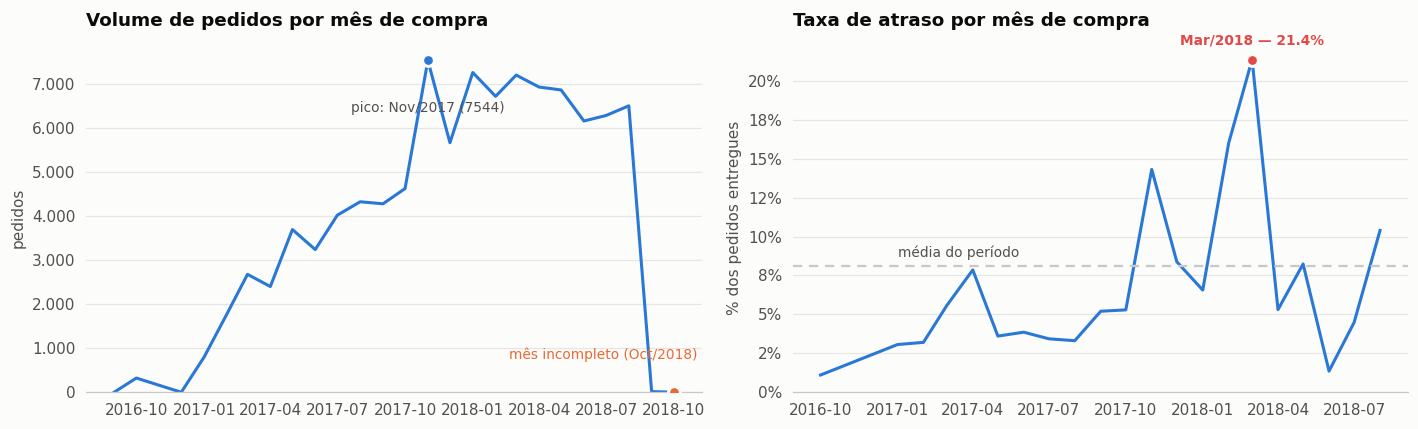

Período: Sep/2016 a Oct/2018 (25 meses)
Meses com menos de 100 pedidos (bordas pouco confiáveis):
ano_mes
2016-09-01     4
2016-12-01     1
2018-09-01    16
2018-10-01     4


In [13]:
serie = orders.groupby("ano_mes").size().sort_index()
serie.index = serie.index.to_timestamp()

mensal = orders[orders["atrasado"].notna()].groupby("ano_mes").agg(
    pedidos=("order_id", "size"), taxa=("atrasado", "mean")
)
mensal = mensal[mensal["pedidos"] >= 100]  # descarta pontas com volume irrisório
mensal.index = mensal.index.to_timestamp()
taxa = mensal["taxa"].astype(float) * 100
taxa_media = float(orders["atrasado"].mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pico_x, pico_y = serie.idxmax(), serie.max()
fim_x, fim_y = serie.index[-1], serie.iloc[-1]
axes[0].plot(serie.index, serie.values, color=BLUE)
axes[0].scatter([pico_x], [pico_y], color=BLUE, s=60, zorder=3, edgecolor=SURFACE, linewidth=2)
axes[0].scatter([fim_x], [fim_y], color=ORANGE, s=60, zorder=3, edgecolor=SURFACE, linewidth=2)
axes[0].annotate(f"pico: {pico_x:%b/%Y} ({pico_y})", xy=(pico_x, pico_y), xytext=(0, -34),
                 textcoords="offset points", fontsize=9, color=INK_SOFT, ha="center")
axes[0].annotate(f"mês incompleto ({fim_x:%b/%Y})", xy=(fim_x, fim_y), xytext=(-46, 22),
                 textcoords="offset points", fontsize=9, color=ORANGE, ha="center")
axes[0].set_title("Volume de pedidos por mês de compra")
axes[0].set_ylabel("pedidos")
axes[0].yaxis.set_major_formatter(MILHAR)

pior_x, pior_y = taxa.idxmax(), taxa.max()
axes[1].plot(taxa.index, taxa.values, color=BLUE)
axes[1].axhline(taxa_media, color=LINHA, linewidth=1.5, linestyle=(0, (4, 3)))
axes[1].annotate("média do período", xy=(taxa.index[1], taxa_media), xytext=(0, 6),
                 textcoords="offset points", fontsize=9, color=INK_SOFT)
axes[1].scatter([pior_x], [pior_y], color=RED, s=60, zorder=3, edgecolor=SURFACE, linewidth=2)
axes[1].annotate(f"{pior_x:%b/%Y} — {pior_y:.1f}%", xy=(pior_x, pior_y), xytext=(0, 10),
                 textcoords="offset points", ha="center", fontsize=9, color=RED, fontweight="semibold")
axes[1].set_title("Taxa de atraso por mês de compra")
axes[1].set_ylabel("% dos pedidos entregues")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))

for ax in axes:
    ax.set_ylim(0)
    ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

print(f"Período: {serie.index[0]:%b/%Y} a {serie.index[-1]:%b/%Y} ({len(serie)} meses)")
print("Meses com menos de 100 pedidos (bordas pouco confiáveis):")
print(serie[serie < 100].to_string())

> **Cuidado ao tratar isto como série temporal:** as pontas são artefato de coleta — os primeiros meses de 2016 têm volume irrisório e o último mês está truncado no meio. Para tendência ou sazonalidade, recorte a janela densa (aprox. jan/2017 a ago/2018).

## 9. Resumo e conclusões

In [14]:
status = orders["order_status"].value_counts()
status_pct = orders["order_status"].value_counts(normalize=True) * 100
entregues = orders[orders["order_status"] == "delivered"]

print("=" * 64)
print("RESUMO — olist_orders_dataset.csv")
print("=" * 64)
print(f"Pedidos                      : {len(orders)}")
print(f"Colunas                      : 8 originais + {orders.shape[1] - 8} derivadas")
print(f"Período de compra            : {orders['order_purchase_timestamp'].min():%d/%m/%Y} a {orders['order_purchase_timestamp'].max():%d/%m/%Y}")
print(f"Granularidade                : 1 linha = 1 pedido ({'confirmado' if orders['order_id'].is_unique else 'HÁ DUPLICATAS'})")
print("-" * 64)
print(f"Entregues (delivered)        : {int(status['delivered'])} ({status_pct['delivered']:.2f}%)")
print(f"Cancelados                   : {int(status.get('canceled', 0))} ({status_pct.get('canceled', 0):.2f}%)")
print(f"Alertas do profiling         : {len(alertas)}")
print("-" * 64)
print(f"Entrega — mediana            : {entregues['d_entrega_total'].median():.1f} dias")
print(f"Entrega — média              : {entregues['d_entrega_total'].mean():.1f} dias")
print(f"Entrega — p95                : {entregues['d_entrega_total'].quantile(0.95):.1f} dias")
print(f"Aprovação — mediana          : {orders['h_aprovacao'].median():.1f} horas")
print(f"Prazo prometido — mediana    : {orders['d_prazo_prometido'].median():.1f} dias")
print(f"Folga sobre o prazo — mediana: {entregues['d_folga'].median():.1f} dias")
print(f"Taxa de atraso               : {taxa_media:.2f}%")
print(f"Linhas com inconsistência    : {int(relatorio['linhas'].sum())} (soma das checagens)")
print("=" * 64)
print("Relatórios HTML gerados em reports/:")
for p in sorted(REPORTS_DIR.glob("olist_orders_profiling*.html")):
    print(f"  · {p.name}  ({p.stat().st_size / 1024**2:.1f} MB)")

RESUMO — olist_orders_dataset.csv
Pedidos                      : 99441
Colunas                      : 8 originais + 9 derivadas
Período de compra            : 04/09/2016 a 17/10/2018
Granularidade                : 1 linha = 1 pedido (confirmado)
----------------------------------------------------------------
Entregues (delivered)        : 96478 (97.02%)
Cancelados                   : 625 (0.63%)
Alertas do profiling         : 5
----------------------------------------------------------------
Entrega — mediana            : 10.2 dias
Entrega — média              : 12.6 dias
Entrega — p95                : 29.3 dias
Aprovação — mediana          : 0.3 horas
Prazo prometido — mediana    : 23.2 dias
Folga sobre o prazo — mediana: 11.9 dias
Taxa de atraso               : 8.11%
Linhas com inconsistência    : 217 (soma das checagens)
Relatórios HTML gerados em reports/:
  · olist_orders_profiling.html  (1.7 MB)
  · olist_orders_profiling_comparativo.html  (0.8 MB)
  · olist_orders_profiling_enr

### O que a exploração estabelece

1. **Granularidade** — uma linha por pedido, `order_id` único. `customer_id` também é único: esta tabela sozinha **não** identifica clientes recorrentes.
2. **Nulos são estruturais** — concentrados nas datas de postagem/entrega de pedidos não concluídos, e correlacionados entre si (heatmap de missing). Imputar por média/mediana seria erro conceitual: ou se filtra a população, ou a ausência vira feature booleana.
3. **Base desbalanceada** — `delivered` domina (~97%). Qualquer alvo baseado em cancelamento é problema de classe rara.
4. **Tempos com cauda longa** — entrega mediana bem abaixo da média. Use mediana/percentis; considere log-transformação se for alvo de regressão.
5. **Prazo prometido é conservador** — folga mediana grande e positiva. O prazo estimado é decisão comercial, não previsão.
6. **Bordas temporais ruins** — 2016 e o último mês são incompletos e devem ser recortados em análises de tendência.
7. **Inconsistências pontuais** — poucas linhas violam a ordem lógica dos eventos; documente a regra de tratamento antes de modelar.

### Próximos passos

- **Enriquecer com joins**: `olist_customers` (`customer_unique_id`, estado, cidade), `olist_order_items` (valor, frete, vendedor), `olist_order_reviews` (nota), `olist_order_payments` (forma e parcelas).
- **Hipótese natural**: atraso na entrega → nota baixa na review. Cruzar `d_folga` com `review_score` é a primeira análise bivariada a fazer.
- **Dimensão geográfica**: tempo de entrega por estado do cliente — a variância regional costuma ser o principal driver no Brasil.
- **Persistir o dataset tratado** em `data/interim/` com as features de tempo e as regras de limpeza aplicadas.
- **Profiling em CI**: `perfil.get_description()` permite transformar os alertas em asserções de qualidade (`tests/test_data.py`), detectando regressão sempre que o dado for atualizado.

### Possíveis alvos de modelagem

| Alvo | Tipo | Observação |
|---|---|---|
| `d_entrega_total` | Regressão | Prever tempo de entrega no momento da compra |
| `atrasado` | Classificação binária | Alerta antecipado de atraso |
| `order_status == 'canceled'` | Classificação binária | Classe rara (< 1%), exige tratamento específico |

> **Regra de ouro contra vazamento:** para prever no momento da compra, só entram features conhecidas **naquele instante** — `order_delivered_carrier_date` e `order_delivered_customer_date` são futuro e não podem ser preditores.